## Imports & SQL connection

Takes care of the needed imports and set the SqlHandler object ready to be used


In [32]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Adjust this path to your project root folder
project_root = r"C:\Users\Martijn\PycharmProjects\CareerLegacy"

if project_root not in sys.path:
    sys.path.append(project_root)

from CareerLegacyDb.Setup.Python.SqlHandler import SqlHandler

sql_handler = SqlHandler()

## DataFrame definitions
Create a couple of DataFrames using Pandas

In [28]:
query = "SELECT * FROM person_info;"
df_person_info = pd.read_sql(query, con=sql_handler.connection)

query = "SELECT * FROM countries;"
df_countries = pd.read_sql(query, con=sql_handler.connection)

query = "SELECT * FROM regions;"
df_regions = pd.read_sql(query, con=sql_handler.connection)

C:\Users\Martijn\AppData\Local\Temp\ipykernel_28024\1810039734.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_person_info = pd.read_sql(query, con=sql_handler.connection)
C:\Users\Martijn\AppData\Local\Temp\ipykernel_28024\1810039734.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_countries = pd.read_sql(query, con=sql_handler.connection)
C:\Users\Martijn\AppData\Local\Temp\ipykernel_28024\1810039734.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_regions = pd.read_sql(query, con=sql_handler.connection

## Playground Graphs

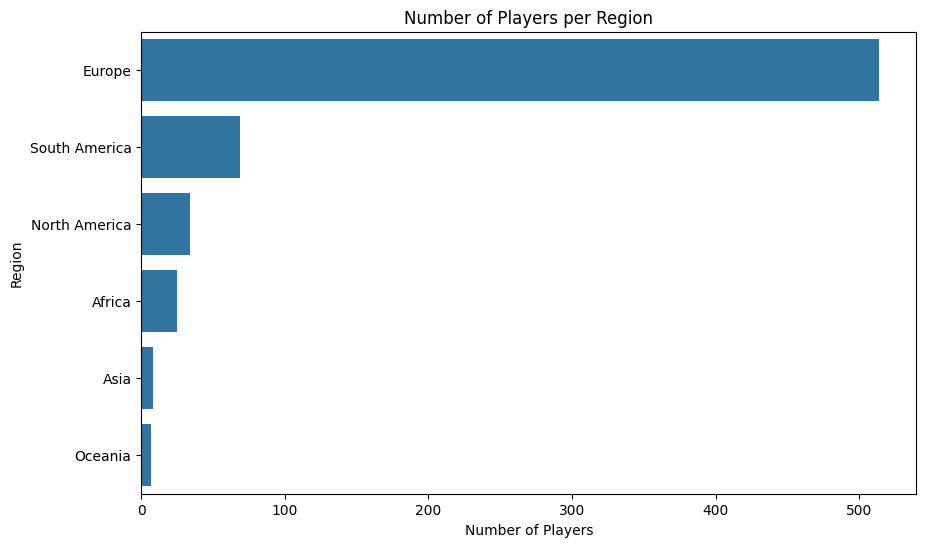

In [44]:
# Merge countries with regions first
df_countries_regions = df_countries.merge(
    df_regions,
    left_on='region_uuid',  # assuming countries has region_uuid
    right_on='uuid',        # region table primary key
    how='left',
    suffixes=('_country', '_region')
)

# Then merge with person_info
df_person_full = df_person_info.merge(
    df_countries_regions,
    left_on='country_uuid',
    right_on='uuid_country',
    how='left'
)

# Count players per region
players_per_region = df_person_full.groupby('name_region').size().reset_index(name='player_count')

# Sort by player_count for nicer plotting
players_per_region_sorted = players_per_region.sort_values('player_count', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    x='player_count',
    y='name_region',
    data=players_per_region_sorted
)

plt.xlabel("Number of Players")
plt.ylabel("Region")
plt.title("Number of Players per Region")
plt.show()


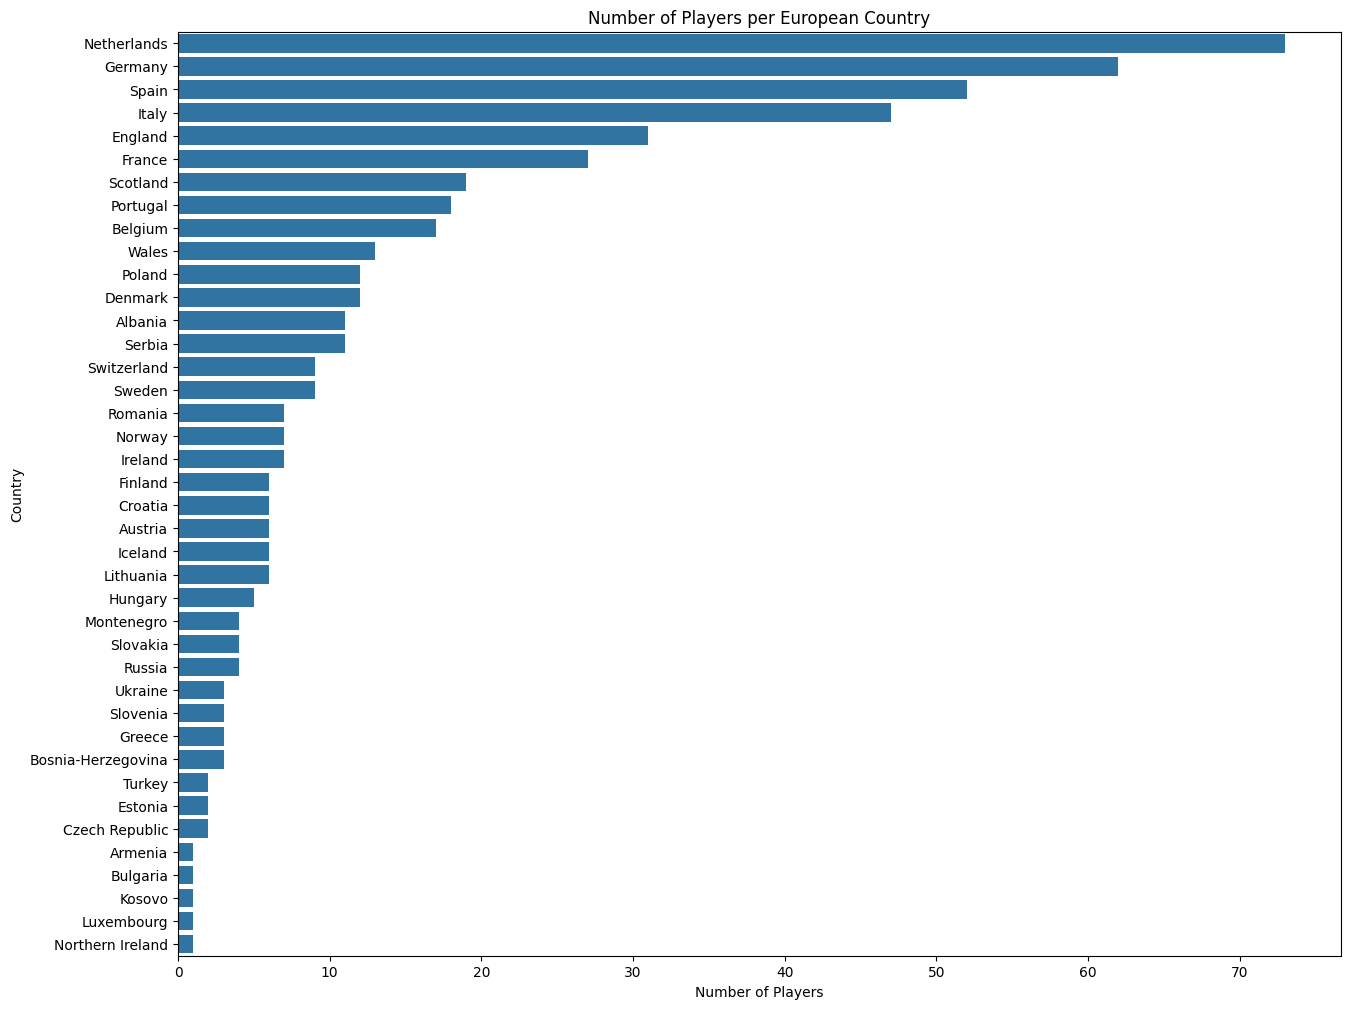

In [63]:
df_europe = df_person_full[df_person_full["name_region"] == "Europe"]
df_south_america = df_person_full[df_person_full["name_region"] == "South America"]
df_north_america = df_person_full[df_person_full["name_region"] == "North America"]
df_africa = df_person_full[df_person_full["name_region"] == "Africa"]
df_asia = df_person_full[df_person_full["name_region"] == "Asia"]
df_oceania = df_person_full[df_person_full["name_region"] == "Oceania"]

dataframe_per_continent = [("Europe", df_europe),
                           ("South America", df_south_america),
                           ("North America", df_north_america),
                           ("Africa", df_africa),
                           ("Asia", df_asia),
                           ("Oceania", df_oceania)]

# Count players per country
europe_player_per_country = df_europe.groupby('name_country').size().reset_index(name='player_count')

# Sort by player_count for nicer plotting
europe_player_per_country_sorted = europe_player_per_country.sort_values('player_count', ascending=False)

plt.figure(figsize=(15,12))
sns.barplot(
    x='player_count',
    y='name_country',
    data=europe_player_per_country_sorted
)

plt.xlabel("Number of Players")
plt.ylabel("Country")
plt.title("Number of Players per European Country")
plt.show()

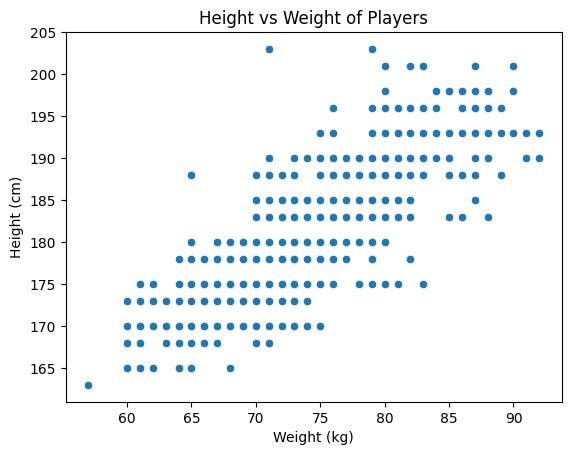

In [77]:
sns.scatterplot(x=df_person_full["weight_kg"], y=df_person_full["height_cm"], data=df_person_full)

plt.title("Height vs Weight of Players")  # plot title
plt.ylabel("Height (cm)")                 # y-axis label
plt.xlabel("Weight (kg)")                 # x-axis label
plt.show()

# # Example: height vs weight
# corr = df_person_full['height_cm'].corr(df_person_full['weight_kg'])
# print("Correlation:", corr)


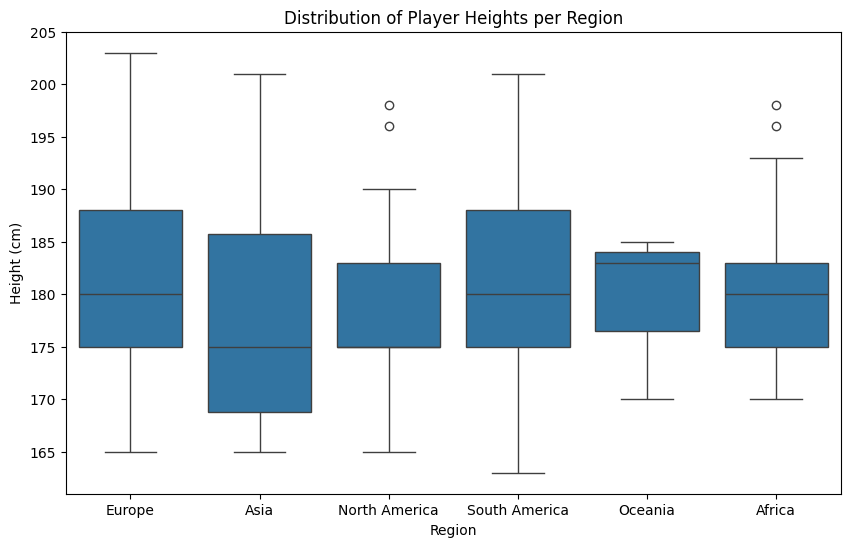

In [88]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='name_region',
    y='height_cm',
    data=df_person_full,
)

plt.xlabel("Region")
plt.ylabel("Height (cm)")
plt.title("Distribution of Player Heights per Region")
plt.show()

In [96]:
df_person_full.head()

,uuid,first_name,last_name,country_uuid,career_mode_uuid,height_cm,weight_kg,birthyear,uuid_country,name_country,region_uuid,uuid_region,name_region
0,0095fe03-bfa1-4902-a1b8-30fe444fb547,Thomas,Dierssen,13d22354-ff0e-40ff-b17a-1a66a3d002c8,75ff172f-cb41-467c-9ba4-304998c81e96,170,74,2002,13d22354-ff0e-40ff-b17a-1a66a3d002c8,Germany,d6000df6-33ad-4a74-a306-fb51b0242caf,d6000df6-33ad-4a74-a306-fb51b0242caf,Europe
1,00d248ff-4d04-4f32-bf68-7076908d0269,Tomasz,Tomasik,056644d1-8e6e-4e27-9cc0-93e2b99bd2e4,db0cdf2e-49a0-46b7-8de7-eeaa9cdfe587,183,80,2002,056644d1-8e6e-4e27-9cc0-93e2b99bd2e4,Poland,d6000df6-33ad-4a74-a306-fb51b0242caf,d6000df6-33ad-4a74-a306-fb51b0242caf,Europe
2,0195c72d-922f-4134-86f2-6955b4359997,Raphael,Varane,aa02d251-59e9-4938-b686-a78186340d28,4fc3f7b6-1119-43ce-8ce5-3e645b2428d8,190,76,1994,aa02d251-59e9-4938-b686-a78186340d28,France,d6000df6-33ad-4a74-a306-fb51b0242caf,d6000df6-33ad-4a74-a306-fb51b0242caf,Europe
3,01b9e221-638c-4ac5-81d0-7996fda9159f,Mohammed,Sefiani,59245803-6b44-4308-a994-46324595d4f0,50c2167a-7a3c-4ff7-9b32-978ccca76a78,201,83,2001,59245803-6b44-4308-a994-46324595d4f0,Saudi Arabia,3b0ba464-25e7-46c4-9674-9fc7543040ba,3b0ba464-25e7-46c4-9674-9fc7543040ba,Asia
4,0210d894-d4ad-452e-a07c-dcf37e95339c,Oscar,Hamid,d0281762-ad40-4614-9127-0fd402585042,4fc3f7b6-1119-43ce-8ce5-3e645b2428d8,183,85,2003,d0281762-ad40-4614-9127-0fd402585042,United States,e8c5d0df-8df4-4641-8ddb-220561e5c218,e8c5d0df-8df4-4641-8ddb-220561e5c218,North America
